# Exploratory Data Analysis (EDA) - VKontakte Users vs Bots Classification

**Dataset**: VK.com Fake and Real Users Classification Dataset  
**Target Variable**: `target` (binary classification)  

## 1. Setup and Data Loading

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configure visualization settings
%matplotlib inline
plt.style.use('ggplot')
sns.set_palette('pastel')
pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Initial Data Inspection

In [1]:
# Load dataset (replace with your actual filename)
raw_data_path = '../data/raw/bots_vs_users.csv'
df = pd.read_csv(raw_data_path)

# Basic dataset inspection
print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("=== First 3 Samples ===")
df.head(3)

=== Dataset Shape ===
Rows: 5874, Columns: 60

=== First 3 Samples ===


,has_domain,has_birth_date,has_photo,can_post_on_wall,can_send_message,has_website,gender,has_short_name,has_first_name,has_last_name,access_to_closed_profile,is_profile_closed,target,has_nickname,has_maiden_name,has_mobile,all_posts_visible,audio_available,has_interests,has_books,has_tv,has_quotes,has_about,has_games,has_movies,has_activities,has_music,can_add_as_friend,can_invite_to_group,subscribers_count,is_blacklisted,has_career,has_military_service,has_hometown,marital_status,has_universities,has_schools,has_relatives,is_verified,is_confirmed,has_status,posts_count,avg_likes,links_ratio,hashtags_ratio,avg_keywords,avg_text_length,attachments_ratio,avg_comments,reposts_ratio,ads_ratio,avg_views,posting_frequency_days,phone_numbers_ratio,avg_text_uniqueness,city,has_occupation,occupation_type_university,occupation_type_work,has_personal_data
0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
1,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown


## 3. Data Structure Analysis

In [2]:
# Data types and missing values analysis
print("=== Data Types ===")
type_info = pd.DataFrame(df.dtypes, columns=['Data Type'])
type_info['Missing Values'] = df.isna().sum()
type_info['% Missing'] = (type_info['Missing Values'] / len(df)) * 100
display(type_info)

=== Data Types ===


,Data Type,Missing Values,% Missing
has_domain,object,0,0.000000
has_birth_date,object,0,0.000000
has_photo,object,0,0.000000
can_post_on_wall,object,0,0.000000
can_send_message,object,0,0.000000
has_website,object,0,0.000000
gender,object,0,0.000000
has_short_name,object,0,0.000000
has_first_name,object,0,0.000000
has_last_name,object,0,0.000000


## 4. Target Variable Exploration

=== Class Distribution ===


target
1    50.0
0    50.0
Name: proportion, dtype: float64

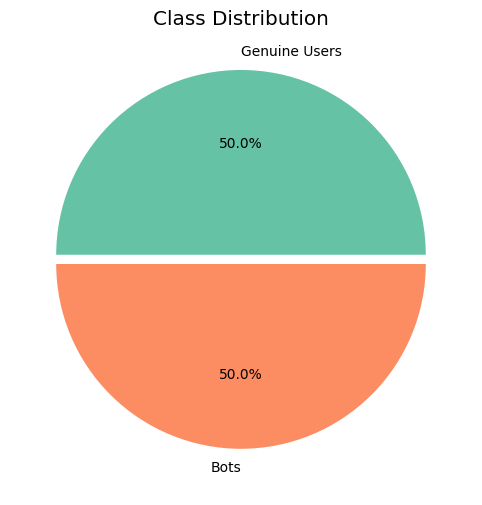

In [3]:
# the target column is named 'target'
target_col = 'target'

print("=== Class Distribution ===")
class_dist = df[target_col].value_counts(normalize=True).mul(100)
display(class_dist)

# Visualization
plt.pie(class_dist, 
        labels=['Genuine Users', 'Bots'],
        autopct='%1.1f%%',
        colors=['#66c2a5', '#fc8d62'],
        explode=(0.05, 0))
plt.title('Class Distribution')
plt.show()

## 5. Feature Space Investigation

In [4]:
# Numerical features analysis
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"\n=== Numerical Features Summary ({len(num_cols)} features) ===")
display(df[num_cols].describe().T)


=== Numerical Features Summary (15 features) ===


,count,mean,std,min,25%,50%,75%,max
target,5874.0,0.500000,0.500043,0.0,0.000,0.50,1.000,1.00
posts_count,1391.0,18.629044,4.231994,1.0,20.000,20.00,20.000,20.00
avg_likes,1391.0,19.552487,41.954881,0.0,0.400,7.60,26.075,894.90
links_ratio,1391.0,0.156463,0.202730,0.0,0.000,0.10,0.200,1.00
hashtags_ratio,1391.0,0.143918,0.187085,0.0,0.000,0.05,0.200,1.00
avg_keywords,1391.0,7.730661,11.278711,0.0,1.100,3.40,7.850,61.60
avg_text_length,1391.0,544.752035,746.728130,0.0,86.600,267.80,616.850,5841.25
attachments_ratio,1391.0,0.895945,0.170084,0.0,0.850,0.95,1.000,1.00
avg_comments,1391.0,0.610812,2.461709,0.0,0.000,0.00,0.200,64.05
reposts_ratio,1391.0,0.433638,0.397830,0.0,0.050,0.30,0.900,1.00


In [5]:
# Categorical features analysis
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\n=== Categorical Features Summary ({len(cat_cols)} features) ===")
display(df[cat_cols].describe(include='object').T)


=== Categorical Features Summary (45 features) ===


,count,unique,top,freq
has_domain,5874,2,1.0,5850
has_birth_date,5874,2,1.0,5018
has_photo,5874,3,1.0,3232
can_post_on_wall,5874,3,0.0,5623
can_send_message,5874,3,0.0,3249
has_website,5874,3,0.0,4436
gender,5874,4,1.0,4512
has_short_name,5874,2,1.0,5850
has_first_name,5874,2,1.0,5850
has_last_name,5874,3,1.0,5844


In [6]:
# Unique values analysis
print("\n=== Unique Values Per Column ===")
unique_counts = pd.DataFrame({
    'Unique Values': df.nunique(),
    '% Unique': (df.nunique() / len(df)) * 100
})
display(unique_counts.sort_values(by='Unique Values'))


=== Unique Values Per Column ===


,Unique Values,% Unique
has_domain,2,0.034048
has_occupation,2,0.034048
is_blacklisted,2,0.034048
target,2,0.034048
has_first_name,2,0.034048
has_short_name,2,0.034048
has_personal_data,2,0.034048
has_birth_date,2,0.034048
has_website,3,0.051073
can_add_as_friend,3,0.051073


## 6. Advanced Visualizations

=== Feature Correlation Matrix ===


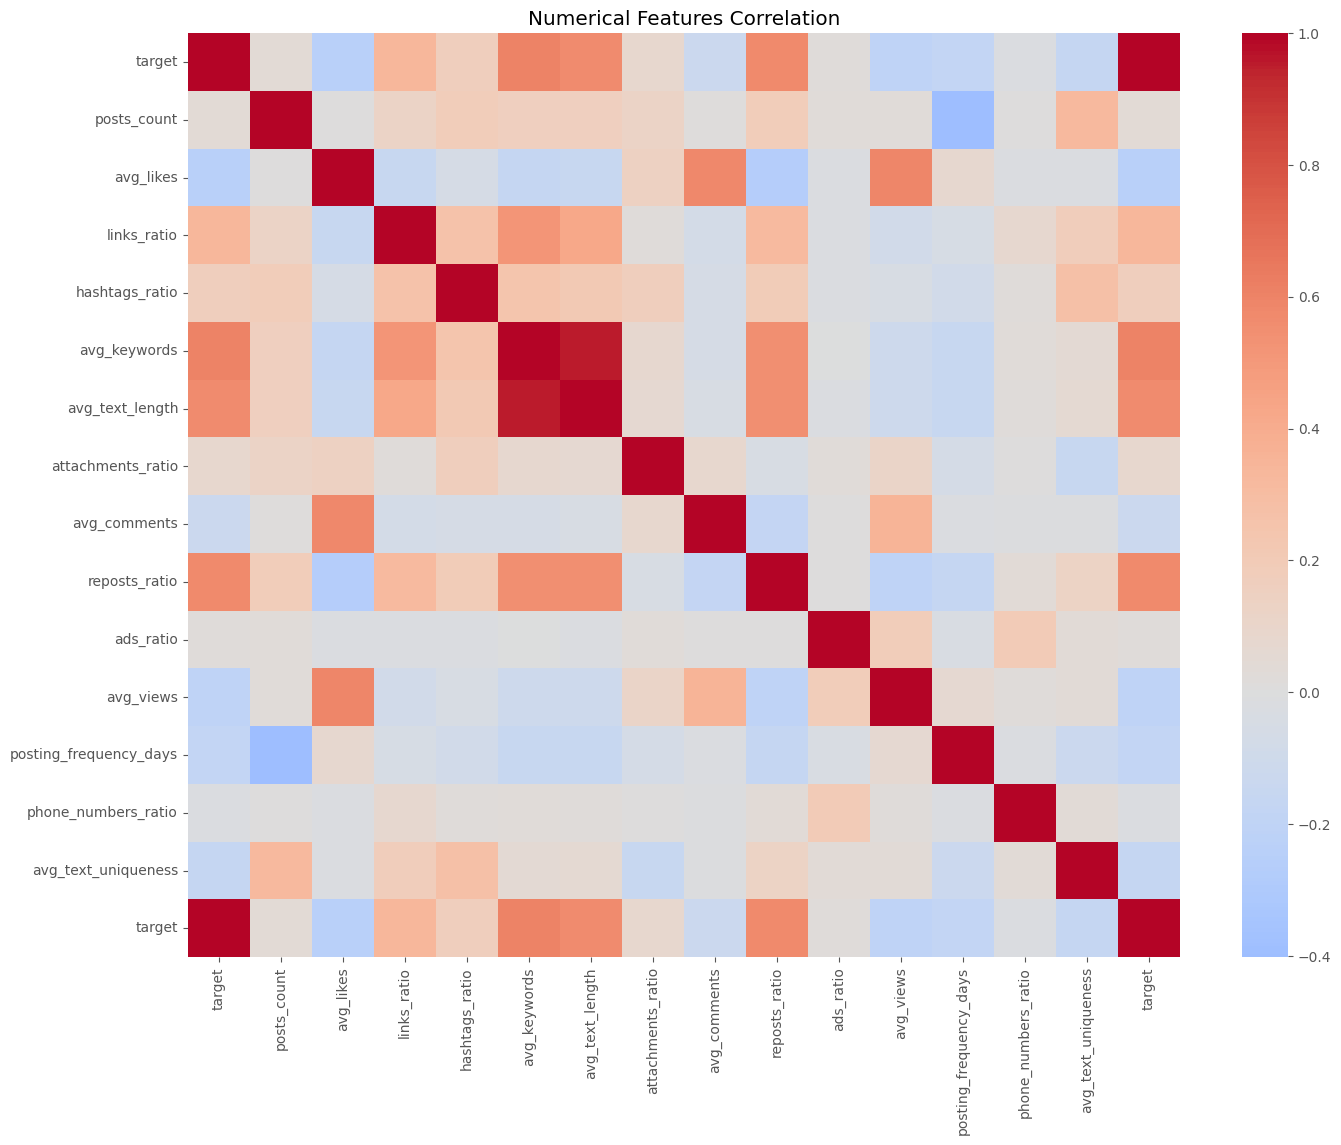

In [7]:
# Correlation analysis
print("=== Feature Correlation Matrix ===")
corr_matrix = df[num_cols + [target_col]].corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Numerical Features Correlation')
plt.show()

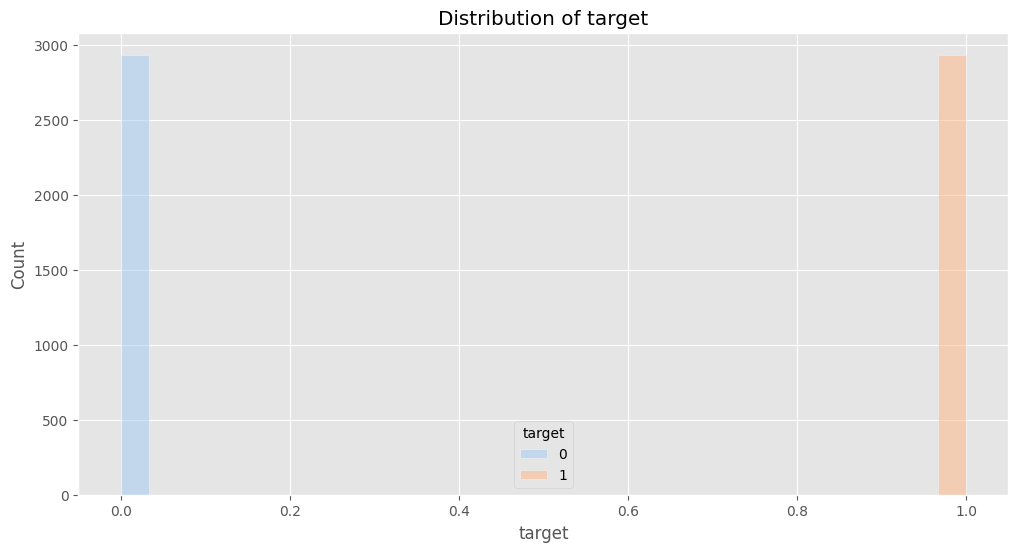

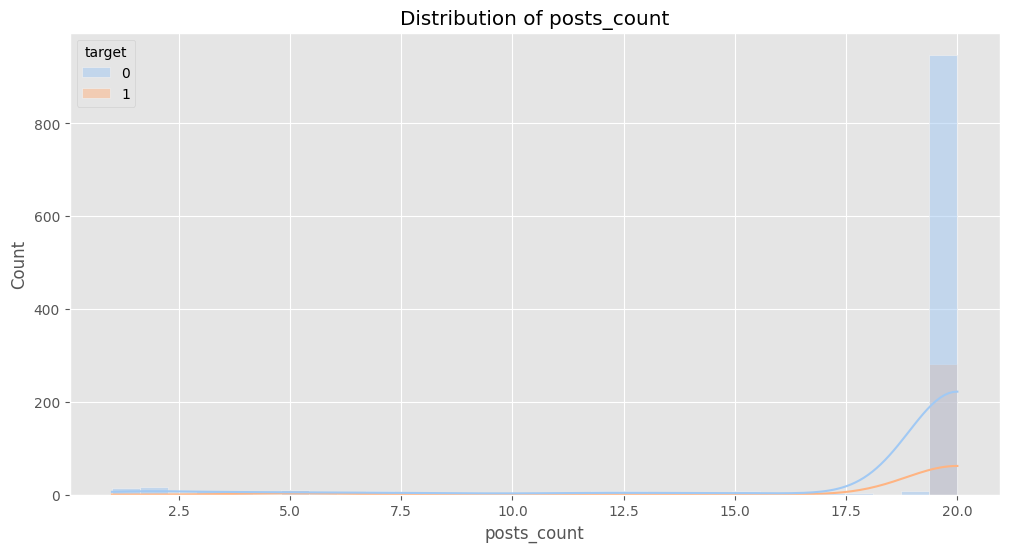

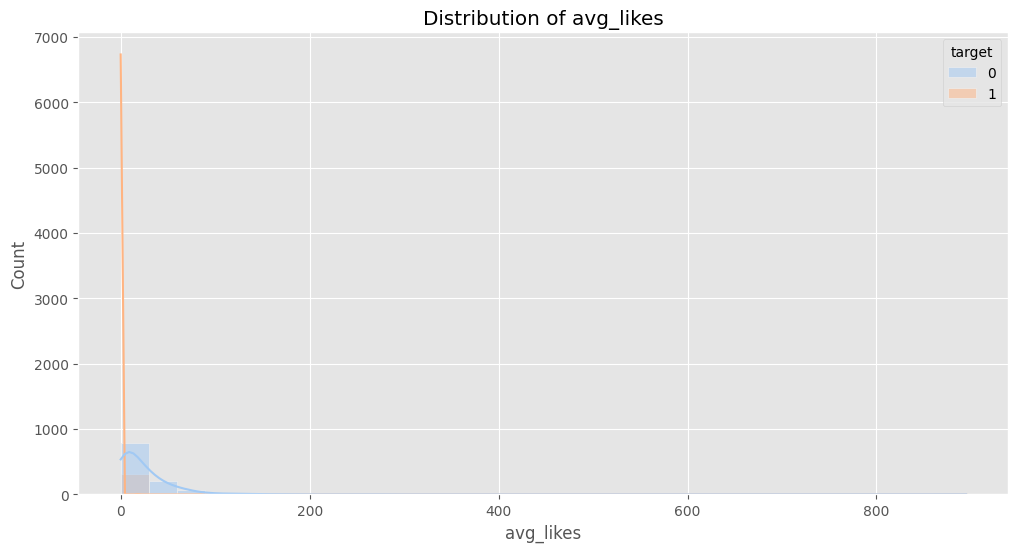

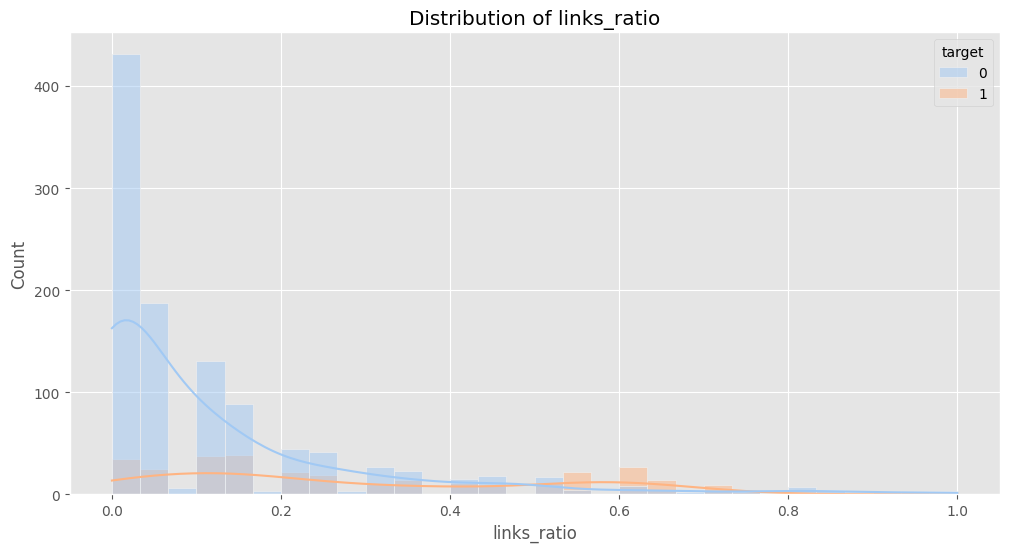

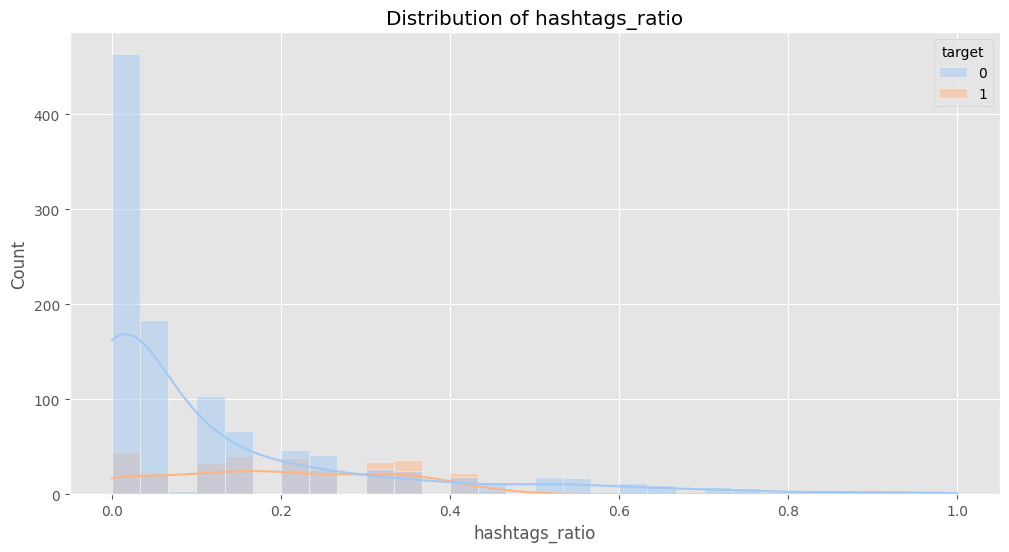

In [8]:
# Numerical features distribution
for col in num_cols[:5]:  # First 5 numerical features
    plt.figure()
    sns.histplot(data=df, x=col, hue=target_col, kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

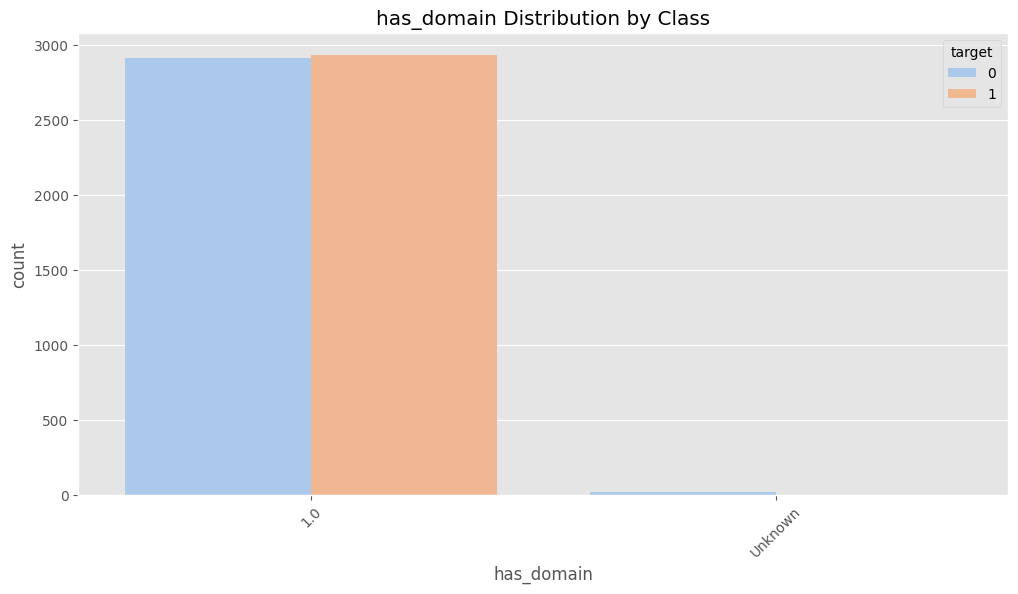

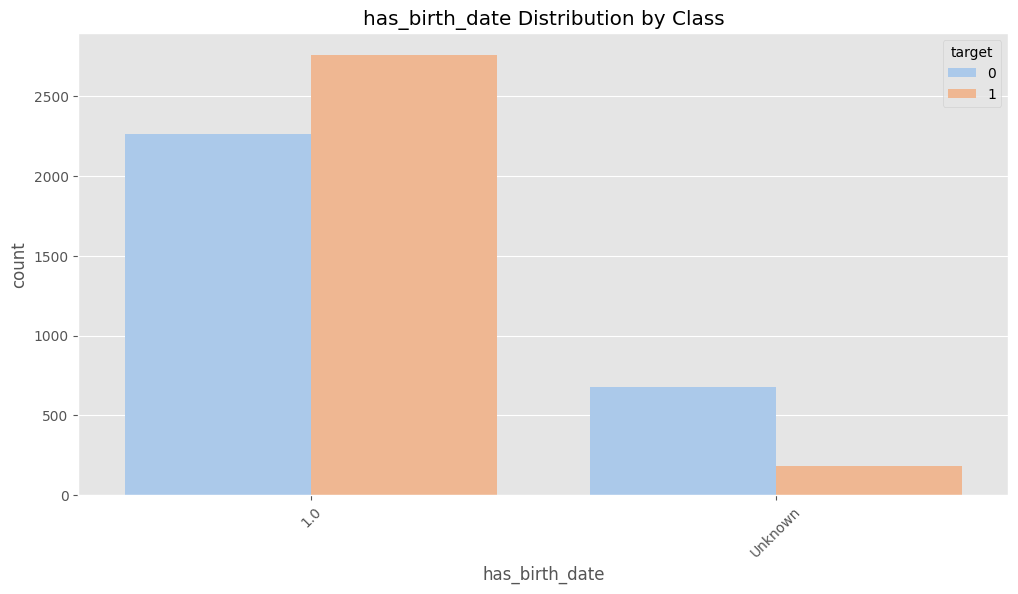

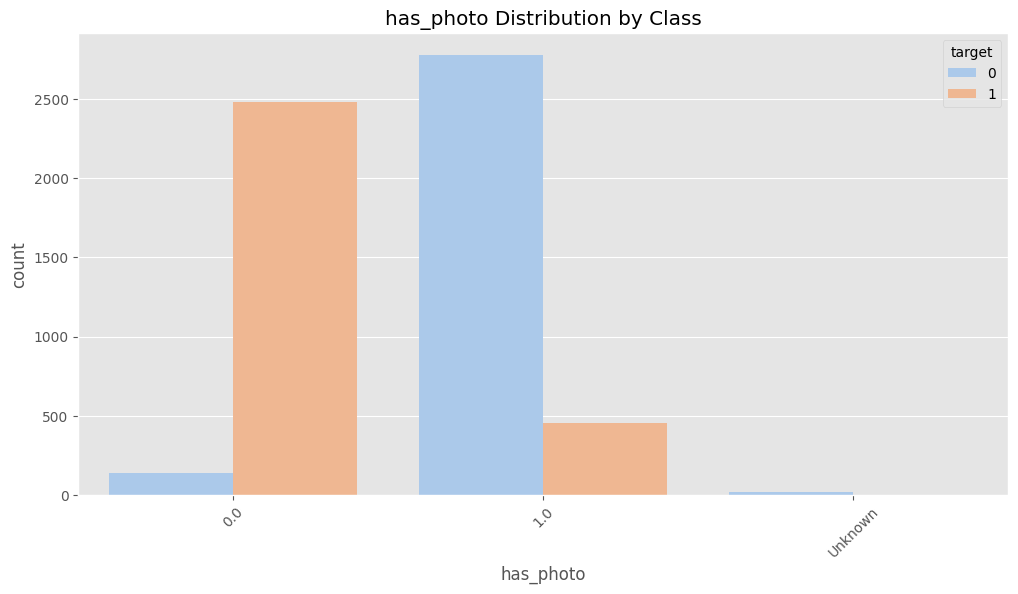

In [9]:
# Categorical features analysis
for col in cat_cols[:3]:  # First 3 categorical features
    plt.figure()
    sns.countplot(data=df, x=col, hue=target_col)
    plt.title(f'{col} Distribution by Class')
    plt.xticks(rotation=45)
    plt.show()

## 7. Advanced Analysis

In [10]:
# Temporal pattern analysis (if time-related features exist)
time_cols = [col for col in df.columns if 'time' in col or 'date' in col]
if time_cols:
    print(f"\n=== Temporal Features ({len(time_cols)} features) ===")
    for col in time_cols:
        print(f"Feature: {col}")



=== Temporal Features (1 features) ===
Feature: has_birth_date


In [11]:
# Constant feature check
constant_features = [col for col in df.columns if df[col].nunique() == 1]
print("\n=== Constant Features ===")
print(f"{len(constant_features)} constant features found:", constant_features)


=== Constant Features ===
0 constant features found: []
